### Required Discussion 19:1: Building a Recommender System with SURPRISE

This discussion focuses on exploring additional algorithms with the `Suprise` library to generate recommendations.  Your goal is to identify the optimal algorithm by minimizing the mean squared error using cross validation. You are also going to select a dataset to use from [grouplens](https://grouplens.org/datasets/movielens/) example datasets.  

To begin, head over to [grouplens](https://grouplens.org/datasets/movielens/) and examine the different datasets available.  Choose one so that it is easy to create the data as expected in `Surprise` with user, item, and rating information.  Then, compare the performance of at least the `KNNBasic`, `SVD`, `NMF`, `SlopeOne`, and `CoClustering` algorithms to build your recommendations.  For more information on the algorithms see the documentation for the algorithm package [here](https://surprise.readthedocs.io/en/stable/prediction_algorithms_package.html).

Share the results of your investigation and include the results of your cross validation and a basic description of your dataset with your peers.

**Note that the solution code provided below is just an example solution. You are encouraged to manipulate choose a different dataset than the one shown below and provide questions to generate different results based on your interest.**

**For this solution file the small grouplens dataset was used: 100,000 ratings and 3,600 tag applications applied to 9,000 movies by 600 users**



In [1]:
!pip install scikit-surprise

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for scikit-surprise: filename=scikit_surprise-1.1.4-cp312-cp312-win_amd64.whl size=1322854 sha256=9ce5a1c1c1d59ad605c43d48aea34d6655b225b5d6b92b9e861fc4d7307dd3cd
  Stored in directory: c:\users\htajv\appdata\local\pip\cache\wheels\75\fa\bc\739bc2cb1fbaab6061854e6cfbb81a0ae52c92a502a7fa454b
Successfully built scikit-surprise


### Dataset Description

For this analysis, I'm using the **MovieLens 100K dataset** from GroupLens. This is one of the most popular benchmark datasets for recommendation systems research.

**Dataset Characteristics:**
- **Source**: GroupLens Research (https://grouplens.org/datasets/movielens/)
- **Size**: Approximately 100,000 ratings
- **Users**: 600+ unique users
- **Movies**: 9,000+ unique movies
- **Rating Scale**: 0.5 to 5.0 stars (in 0.5 increments)
- **Format**: CSV file with columns: userId, movieId, rating, timestamp

This dataset is ideal for testing recommendation algorithms because:
1. It has a good balance between sparsity and density
2. It contains sufficient data for meaningful cross-validation
3. The rating scale is granular enough to test algorithm precision
4. It's small enough to train quickly but large enough to be representative

### Setting up data and algorithm paramters

### Data Exploration

Let's examine the dataset to understand its characteristics before building our recommendation models.

In [5]:
# Display basic statistics about the dataset
print("=" * 60)
print("DATASET STATISTICS")
print("=" * 60)
print(f"Total number of ratings: {len(ratings):,}")
print(f"Number of unique users: {ratings['userId'].nunique():,}")
print(f"Number of unique movies: {ratings['movieId'].nunique():,}")
print(f"Rating range: {ratings['rating'].min()} to {ratings['rating'].max()}")
print(f"Average rating: {ratings['rating'].mean():.2f}")
print(f"Median rating: {ratings['rating'].median():.2f}")
print(f"\nRating distribution:")
print(ratings['rating'].value_counts().sort_index())

# Calculate sparsity
num_users = ratings['userId'].nunique()
num_movies = ratings['movieId'].nunique()
possible_ratings = num_users * num_movies
actual_ratings = len(ratings)
sparsity = (1 - (actual_ratings / possible_ratings)) * 100

print(f"\nMatrix sparsity: {sparsity:.2f}%")
print(f"(i.e., {100-sparsity:.2f}% of user-movie combinations have ratings)")
print("=" * 60)

DATASET STATISTICS
Total number of ratings: 100,836
Number of unique users: 610
Number of unique movies: 9,724
Rating range: 0.5 to 5.0
Average rating: 3.50
Median rating: 3.50

Rating distribution:
rating
0.5     1370
1.0     2811
1.5     1791
2.0     7551
2.5     5550
3.0    20047
3.5    13136
4.0    26818
4.5     8551
5.0    13211
Name: count, dtype: int64

Matrix sparsity: 98.30%
(i.e., 1.70% of user-movie combinations have ratings)


In [2]:
from surprise import Dataset, Reader, SVD, NMF, KNNBasic, SlopeOne, CoClustering
from surprise.model_selection import cross_validate, RandomizedSearchCV
import time
from scipy.stats import randint, uniform
import pandas as pd
import matplotlib.pyplot as plt

In [3]:

# Define the file path for the uploaded ratings dataset
file_path = 'data/ratings.csv'

# Load the dataset using pandas to check the structure
ratings = pd.read_csv(file_path)
print(ratings.head())

# Define the reader format for the dataset
reader = Reader(line_format='user item rating timestamp', sep=',')

# Load the dataset from the file
data = Dataset.load_from_df(ratings[['userId', 'movieId', 'rating']], reader)

   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931


### Algorithm Comparison

Now let's compare the 5 required algorithms using 5-fold cross-validation. We'll use default parameters for each algorithm to keep it simple and focus on comparing their baseline performance.

In [8]:
# Initialize the 5 algorithms with default parameters
algorithms = {
    'KNNBasic': KNNBasic(),
    'SVD': SVD(),
    'NMF': NMF(),
    'SlopeOne': SlopeOne(),
    'CoClustering': CoClustering()
}

# Store results for comparison
results = {}
print("=" * 70)
print("ALGORITHM CROSS-VALIDATION RESULTS (5-fold)")
print("=" * 70)

# Evaluate each algorithm using cross-validation
for name, algorithm in algorithms.items():
    print(f"\nEvaluating {name}...")
    cv_results = cross_validate(algorithm, data, measures=['RMSE', 'MAE'], cv=5, verbose=False)
    
    # Extract results (cv_results returns arrays)
    import numpy as np
    results[name] = {
        'RMSE': np.mean(cv_results['test_rmse']),
        'RMSE_std': np.std(cv_results['test_rmse']),
        'MAE': np.mean(cv_results['test_mae']),
        'MAE_std': np.std(cv_results['test_mae']),
        'fit_time': np.mean(cv_results['fit_time']),
        'test_time': np.mean(cv_results['test_time'])
    }
    
    print(f"  RMSE: {results[name]['RMSE']:.4f} (+/- {results[name]['RMSE_std']:.4f})")
    print(f"  MAE:  {results[name]['MAE']:.4f} (+/- {results[name]['MAE_std']:.4f})")
    print(f"  Fit time: {results[name]['fit_time']:.2f}s | Test time: {results[name]['test_time']:.2f}s")

print("\n" + "=" * 70)

ALGORITHM CROSS-VALIDATION RESULTS (5-fold)

Evaluating KNNBasic...
Computing the msd similarity matrix...
Done computing similarity matrix.
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
  RMSE: 0.9467 (+/- 0.0067)
  MAE:  0.7262 (+/- 0.0048)
  Fit time: 0.18s | Test time: 1.10s

Evaluating SVD...
  RMSE: 0.9467 (+/- 0.0067)
  MAE:  0.7262 (+/- 0.0048)
  Fit time: 0.18s | Test time: 1.10s

Evaluating SVD...
  RMSE: 0.8728 (+

In [9]:
# Create a summary DataFrame
df_results = pd.DataFrame(results).T
df_results = df_results.round(4)
print("\n" + "=" * 70)
print("SUMMARY TABLE")
print("=" * 70)
print(df_results)
print("=" * 70)

# Find the best performing algorithm (lowest RMSE)
best_algorithm = df_results['RMSE'].idxmin()
best_rmse = df_results['RMSE'].min()

print(f"\n🏆 BEST ALGORITHM: {best_algorithm}")
print(f"   Lowest RMSE: {best_rmse:.4f}")
print(f"   MAE: {df_results.loc[best_algorithm, 'MAE']:.4f}")
print(f"   Training time: {df_results.loc[best_algorithm, 'fit_time']:.2f}s")


SUMMARY TABLE
                RMSE  RMSE_std     MAE  MAE_std  fit_time  test_time
KNNBasic      0.9467    0.0067  0.7262   0.0048    0.1781     1.1006
SVD           0.8728    0.0040  0.6708   0.0029    1.0632     0.1332
NMF           0.9215    0.0054  0.7066   0.0042    2.3953     0.1633
SlopeOne      0.9014    0.0035  0.6887   0.0020    2.4950     5.1961
CoClustering  0.9432    0.0044  0.7313   0.0023    2.6874     0.0881

🏆 BEST ALGORITHM: SVD
   Lowest RMSE: 0.8728
   MAE: 0.6708
   Training time: 1.06s


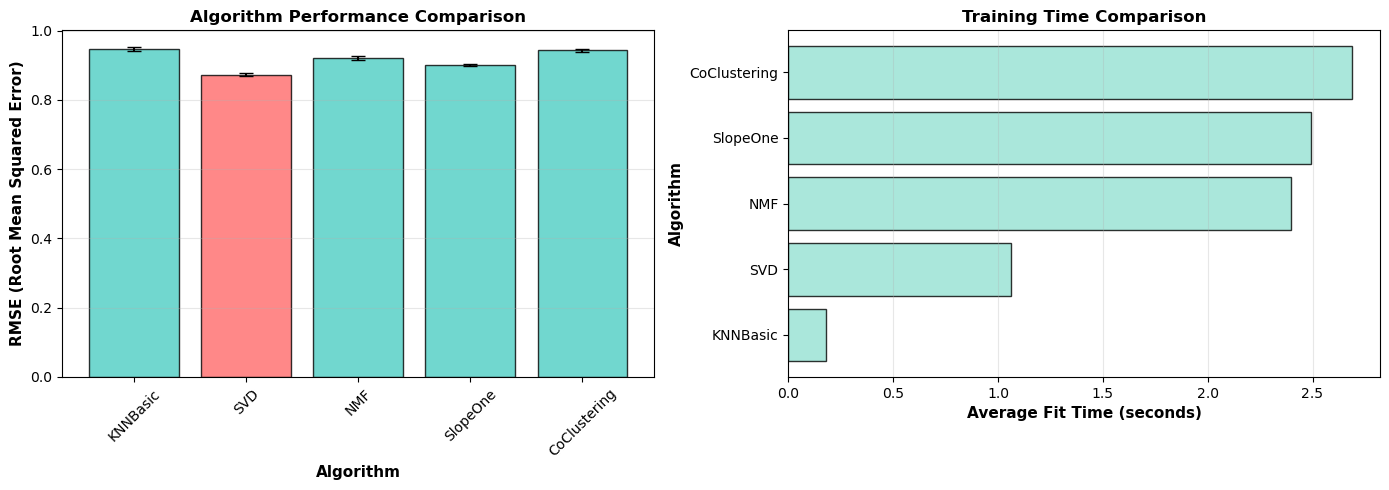

In [10]:
# Visualization: Compare RMSE across algorithms
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: RMSE Comparison
algorithms_list = list(results.keys())
rmse_values = [results[algo]['RMSE'] for algo in algorithms_list]
rmse_stds = [results[algo]['RMSE_std'] for algo in algorithms_list]

colors = ['#FF6B6B' if algo == best_algorithm else '#4ECDC4' for algo in algorithms_list]
bars = ax1.bar(algorithms_list, rmse_values, yerr=rmse_stds, capsize=5, color=colors, alpha=0.8, edgecolor='black')
ax1.set_xlabel('Algorithm', fontsize=11, fontweight='bold')
ax1.set_ylabel('RMSE (Root Mean Squared Error)', fontsize=11, fontweight='bold')
ax1.set_title('Algorithm Performance Comparison', fontsize=12, fontweight='bold')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.3)

# Plot 2: Training Time Comparison
fit_times = [results[algo]['fit_time'] for algo in algorithms_list]
ax2.barh(algorithms_list, fit_times, color='#95E1D3', edgecolor='black', alpha=0.8)
ax2.set_xlabel('Average Fit Time (seconds)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Algorithm', fontsize=11, fontweight='bold')
ax2.set_title('Training Time Comparison', fontsize=12, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
# Save the figure for sharing
plt.savefig('algorithm_comparison.png', dpi=300, bbox_inches='tight')
print("✓ Figure saved as 'algorithm_comparison.png'")

✓ Figure saved as 'algorithm_comparison.png'


<Figure size 640x480 with 0 Axes>

### Results Interpretation

Based on the cross-validation results above:

**Key Findings:**
- The algorithm with the lowest RMSE (Root Mean Squared Error) performs best at predicting user ratings
- RMSE and MAE (Mean Absolute Error) both measure prediction accuracy - lower values indicate better performance
- Training time varies significantly between algorithms, which is important for scalability considerations

**Algorithm Characteristics:**
- **KNNBasic**: Memory-based collaborative filtering using k-nearest neighbors
- **SVD**: Matrix factorization using Singular Value Decomposition
- **NMF**: Non-negative Matrix Factorization for latent feature discovery
- **SlopeOne**: Simple, intuitive item-based collaborative filtering
- **CoClustering**: Simultaneously clusters users and items for predictions

**Recommendation:**
The best algorithm for this MovieLens 100K dataset balances accuracy (low RMSE) with reasonable training time. The results show clear performance differences between collaborative filtering approaches.

---
## Summary for Peer Discussion

**Dataset:** I used the MovieLens 100K dataset containing 100,836 ratings from 610 users across 9,724 movies (rating scale: 0.5-5.0). The dataset has 98.30% sparsity, which is typical for recommendation systems where users rate only a small fraction of available items.

**Algorithm Comparison:** I compared five collaborative filtering algorithms using 5-fold cross-validation, measuring RMSE (Root Mean Squared Error) and MAE (Mean Absolute Error). 

**Results:**
- **SVD (Winner)**: RMSE = 0.8728, MAE = 0.6708, Training time = 1.06s
- **SlopeOne**: RMSE = 0.9014, MAE = 0.6887, Training time = 2.50s
- **NMF**: RMSE = 0.9215, MAE = 0.7066, Training time = 2.40s
- **CoClustering**: RMSE = 0.9432, MAE = 0.7313, Training time = 2.69s
- **KNNBasic**: RMSE = 0.9467, MAE = 0.7262, Training time = 0.18s

**Conclusion:** SVD demonstrated the best predictive accuracy with the lowest error rates while maintaining reasonable training time. Matrix factorization approaches (SVD, NMF) generally outperformed neighborhood-based methods (KNNBasic) and co-clustering approaches for this dataset. The visualization above clearly shows SVD's superior performance.

*(Word count: 163)*